In [1]:
import hw1.data_preprocessing as data
from hw1.model import BinaryClfModel
import hw1.train as train
import hw1.evaluate as evaluate
import numpy as np
import pandas as pd

In [2]:
X, y = data.load_data('../data/cybersequrity.csv')

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = data.split_data(X, y)

In [4]:
scaler = data.train_scaler(X_train)

X_train = data.scale(X_train, scaler=scaler)
X_val = data.scale(X_val, scaler=scaler)
X_test = data.scale(X_test, scaler=scaler)

In [5]:
train_dataloader = data.create_dataloader(X_train, y_train, batch_size=64, shuffle=True)
val_dataloader = data.create_dataloader(X_val, y_val, batch_size=64, shuffle=False)
test_dataloader = data.create_dataloader(X_test, y_test, batch_size=64, shuffle=False)

In [6]:
input_size = X_train.shape[1]
hidden_size = 256
output_size = 1

model = BinaryClfModel(input_size, hidden_size, output_size, n_layers=3)

In [7]:
model

BinaryClfModel(
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)

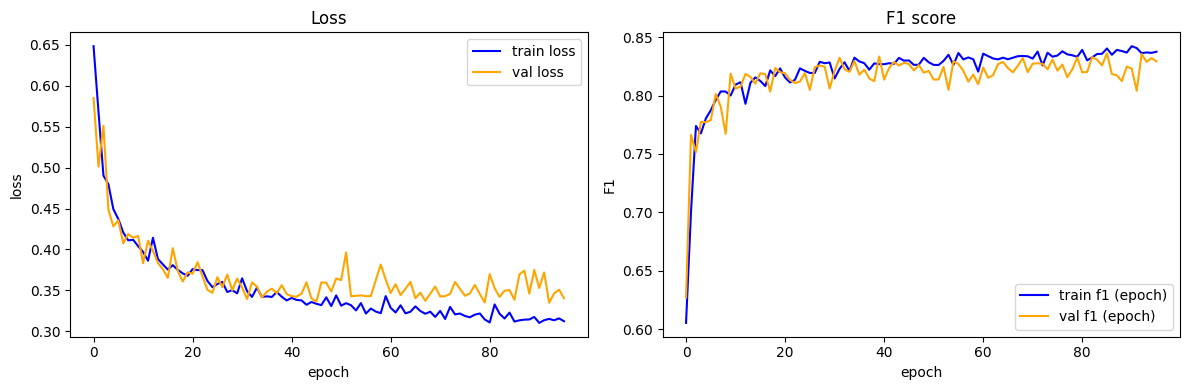

100%|█████████████████████████████████████████████████████| 100/100 [00:41<00:00,  2.40it/s]


In [8]:
train.train_model(train_dataloader=train_dataloader, val_dataloader= val_dataloader,
                  model=model, n_epochs=100, learning_rate=1e-3, eval_step=5
)

In [9]:
y_train.value_counts()

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [ ]:
np.count_nonzero(y_val)
